In [1]:
from google.colab import files

uploaded = files.upload()

Saving adult.csv to adult.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('adult.csv')

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
print(df.shape)

(32561, 15)


In [7]:
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [8]:
le = LabelEncoder()

df['income'] = le.fit_transform(df['income'])

df[['income']].head()

,income
0,0
1,0
2,0
3,0
4,0


In [9]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'workclass',
        'education',
        'marital.status',
        'occupation',
        'relationship',
        'race',
        'sex',
        'native.country'
    ],
    drop_first=True
)

df_encoded.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [10]:
numerical_columns = df_encoded.select_dtypes(
    include=['int64','float64']
).columns

print(numerical_columns)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week', 'income'],
      dtype='object')


In [11]:
standard_scaler = StandardScaler()

standardized_data = standard_scaler.fit_transform(
    df_encoded[numerical_columns]
)

standardized_df = pd.DataFrame(
    standardized_data,
    columns=numerical_columns
)

standardized_df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,3.769612,-1.067997,-0.420060,-0.14592,10.593507,-0.035429,-0.563199
1,3.183112,-0.539169,-0.420060,-0.14592,10.593507,-1.817204,-0.563199
2,2.010110,-0.035220,-0.031360,-0.14592,10.593507,-0.035429,-0.563199
3,1.130359,-0.468215,-2.363558,-0.14592,9.461864,-0.035429,-0.563199
4,0.177296,0.709482,-0.031360,-0.14592,9.461864,-0.035429,-0.563199


In [12]:
minmax_scaler = MinMaxScaler()

normalized_data = minmax_scaler.fit_transform(
    df_encoded[numerical_columns]
)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=numerical_columns
)

normalized_df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,1.000000,0.043987,0.533333,0.0,1.000000,0.397959,0.0
1,0.890411,0.081896,0.533333,0.0,1.000000,0.173469,0.0
2,0.671233,0.118021,0.600000,0.0,1.000000,0.397959,0.0
3,0.506849,0.086982,0.200000,0.0,0.895317,0.397959,0.0
4,0.328767,0.171404,0.600000,0.0,0.895317,0.397959,0.0


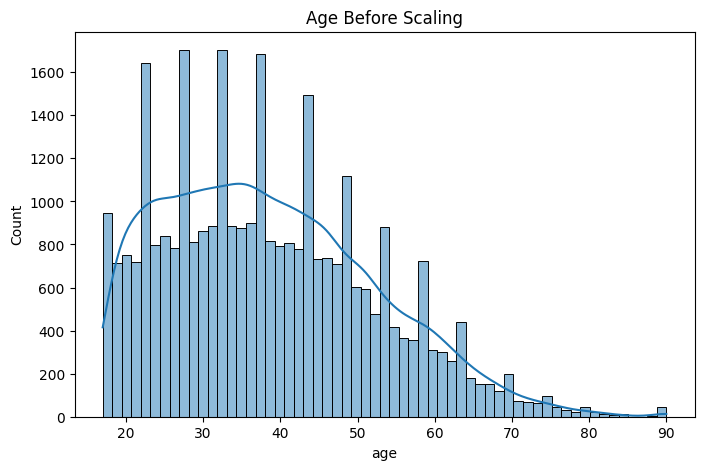

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df_encoded['age'], kde=True)

plt.title("Age Before Scaling")

plt.show()

In [14]:
df_encoded.to_csv(
    'adult_encoded_scaled.csv',
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [15]:
from google.colab import files

files.download('adult_encoded_scaled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>